<a href="https://colab.research.google.com/github/omar192501/super_market_analysis/blob/main/super_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("faresashraf1001/supermarket-sales")

print("Path to dataset files:", path)

100%|██████████| 36.5k/36.5k [00:00<00:00, 13.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/faresashraf1001/supermarket-sales/versions/2


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
df=pd.read_csv('/content/drive/MyDrive/SuperMarket_Analysis.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [16]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

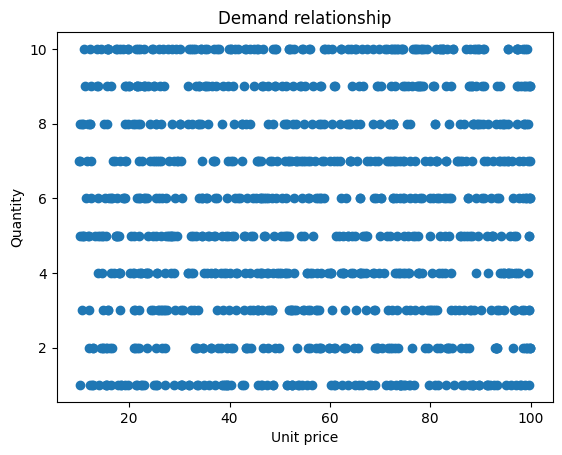

In [17]:
plt.figure()
plt.scatter(df['Unit price'],df['Quantity'])
plt.xlabel('Unit price')
plt.ylabel('Quantity')
plt.title('Demand relationship')
plt.show()

In [18]:
correlation=df['Unit price'].corr(df['Quantity'])
print(correlation)

0.01077756434249727


In [19]:
df=df.sort_values(by=['Unit price'])
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
944,333-23-2632,Alex,Yangon,Member,Male,Health and beauty,10.08,7,3.5280,74.0880,3/28/2019,8:14:00 PM,Cash,70.56,4.761905,3.5280,4.2
572,239-48-4278,Alex,Yangon,Member,Male,Food and beverages,10.13,7,3.5455,74.4555,3/10/2019,7:35:00 PM,Ewallet,70.91,4.761905,3.5455,8.3
784,516-77-6464,Giza,Naypyitaw,Member,Female,Health and beauty,10.16,5,2.5400,53.3400,2/24/2019,1:08:00 PM,Ewallet,50.80,4.761905,2.5400,4.1
822,784-21-9238,Giza,Naypyitaw,Member,Male,Sports and travel,10.17,1,0.5085,10.6785,2/7/2019,2:15:00 PM,Cash,10.17,4.761905,0.5085,5.9
881,115-38-7388,Giza,Naypyitaw,Member,Female,Fashion accessories,10.18,8,4.0720,85.5120,3/30/2019,12:51:00 PM,Credit card,81.44,4.761905,4.0720,9.5


In [25]:
df['pct_change_price']=df['Unit price'].pct_change()
df['pct_change_quantity']=df['Quantity'].pct_change()
df['elasticity']=df['pct_change_price']/df['pct_change_quantity']
df[['Unit price','Quantity','elasticity']].head()

,Unit price,Quantity,elasticity
944,10.08,7,NaN
572,10.13,7,inf
784,10.16,5,-0.010365
822,10.17,1,-0.001230
881,10.18,8,0.000140


In [30]:
x=df[['Unit price']]
y=df['Quantity']
model=LinearRegression()
model.fit(x,y)

LinearRegression()

In [31]:
df['predicted_quantity']=model.predict(x)
df[['Unit price','Quantity','predicted_quantity']].head()

,Unit price,Quantity,predicted_quantity
944,10.08,7,5.455782
572,10.13,7,5.455841
784,10.16,5,5.455877
822,10.17,1,5.455889
881,10.18,8,5.455901


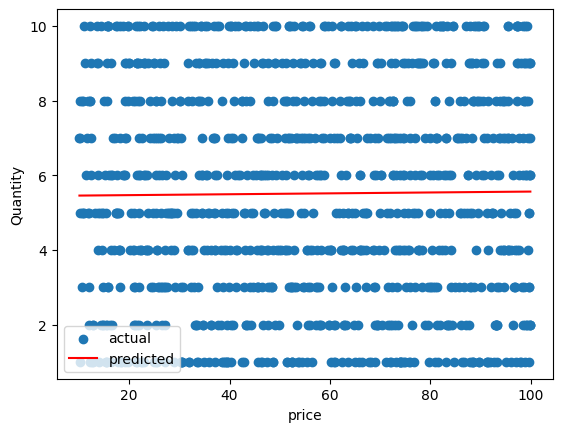

In [34]:
plt.scatter(df['Unit price'],df['Quantity'],label='actual')
plt.plot(df['Unit price'],df['predicted_quantity'],color='red',label='predicted')
plt.xlabel('price')
plt.ylabel('Quantity')
plt.legend()
plt.show()

In [35]:
df['revenue']=df['Unit price']*df['Quantity']
df.sort_values(by=['revenue'],ascending=False).head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,cogs,gross margin percentage,gross income,Rating,pct_change_price,pct_vhange_quantity,pct_change_quantity,elasticity,predicted_quantity,revenue
350,860-79-0874,Giza,Naypyitaw,Member,Female,Fashion accessories,99.30,10,49.65,1042.65,...,993.0,4.761905,49.65,6.6,0.000504,4.000000,4.000000,0.000126,5.561882,993.0
167,687-47-8271,Alex,Yangon,Normal,Male,Fashion accessories,98.98,10,49.49,1039.29,...,989.8,4.761905,49.49,8.7,0.000101,0.111111,0.111111,0.000909,5.561502,989.8
557,283-26-5248,Giza,Naypyitaw,Member,Female,Food and beverages,98.52,10,49.26,1034.46,...,985.2,4.761905,49.26,4.5,0.000406,4.000000,4.000000,0.000102,5.560955,985.2
699,751-41-9720,Giza,Naypyitaw,Normal,Male,Home and lifestyle,97.50,10,48.75,1023.75,...,975.0,4.761905,48.75,8.0,0.000205,0.111111,0.111111,0.001847,5.559742,975.0
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.69,1022.49,...,973.8,4.761905,48.69,4.4,0.000103,0.000000,0.000000,inf,5.559599,973.8


In [36]:
cost_per_unit=10
df['cost']=df['Quantity']*cost_per_unit
df['revenue']=df['Unit price']*df['Quantity']
df['profit']=df['revenue']-df['cost']
df.sort_values(by=['profit'],ascending=False).head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,gross income,Rating,pct_change_price,pct_vhange_quantity,pct_change_quantity,elasticity,predicted_quantity,revenue,cost,profit
350,860-79-0874,Giza,Naypyitaw,Member,Female,Fashion accessories,99.30,10,49.65,1042.65,...,49.65,6.6,0.000504,4.000000,4.000000,0.000126,5.561882,993.0,100,893.0
167,687-47-8271,Alex,Yangon,Normal,Male,Fashion accessories,98.98,10,49.49,1039.29,...,49.49,8.7,0.000101,0.111111,0.111111,0.000909,5.561502,989.8,100,889.8
557,283-26-5248,Giza,Naypyitaw,Member,Female,Food and beverages,98.52,10,49.26,1034.46,...,49.26,4.5,0.000406,4.000000,4.000000,0.000102,5.560955,985.2,100,885.2
699,751-41-9720,Giza,Naypyitaw,Normal,Male,Home and lifestyle,97.50,10,48.75,1023.75,...,48.75,8.0,0.000205,0.111111,0.111111,0.001847,5.559742,975.0,100,875.0
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.69,1022.49,...,48.69,4.4,0.000103,0.000000,0.000000,inf,5.559599,973.8,100,873.8


Text(0.5, 1.0, 'profit vs price')

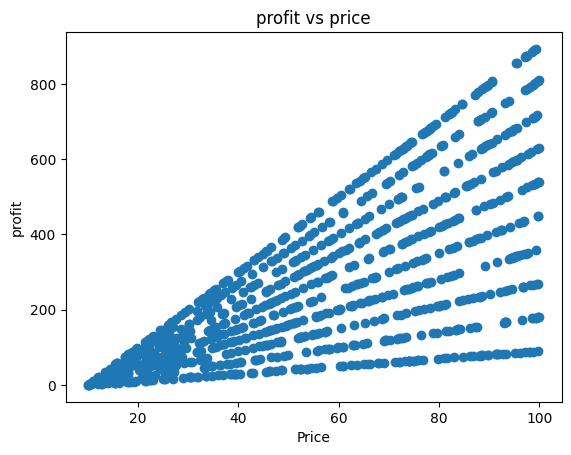

In [37]:
plt.scatter(df['Unit price'],df['profit'])
plt.xlabel('Price')
plt.ylabel('profit')
plt.title('profit vs price')

In [38]:
df['predicted_revenue']=df['Unit price']*df['predicted_quantity']
df['predicted_profit']=df['predicted_revenue']-(cost_per_unit*df['predicted_quantity'])
df.sort_values(by='predicted_profit', ascending=False).head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,pct_change_price,pct_vhange_quantity,pct_change_quantity,elasticity,predicted_quantity,revenue,cost,profit,predicted_revenue,predicted_profit
983,148-41-7930,Giza,Naypyitaw,Normal,Male,Health and beauty,99.96,7,34.986,734.706,...,0.000000,-0.222222,-0.222222,-0.000000,5.562667,699.72,70,629.72,556.044215,500.417543
122,219-22-9386,Cairo,Mandalay,Member,Female,Sports and travel,99.96,9,44.982,944.622,...,0.000400,0.500000,0.500000,0.000801,5.562667,899.64,90,809.64,556.044215,500.417543
930,641-62-7288,Cairo,Mandalay,Normal,Male,Home and lifestyle,99.92,6,29.976,629.496,...,0.000300,2.000000,2.000000,0.000150,5.562620,599.52,60,539.52,555.816955,500.190759
494,437-53-3084,Cairo,Mandalay,Normal,Male,Fashion accessories,99.89,2,9.989,209.769,...,0.000601,-0.666667,-0.666667,-0.000902,5.562584,199.78,20,179.78,555.646513,500.020673
283,667-92-0055,Alex,Yangon,Member,Male,Health and beauty,99.83,6,29.949,628.929,...,0.000100,2.000000,2.000000,0.000050,5.562513,598.98,60,538.98,555.305635,499.680509
